# DOE Data Preprocessing for LUMI Machine Learning (ARIMA Forecasting)

## Objective
This notebook preprocesses the Department of Energy (DOE) Philippine Power Statistics into a clean, analysis-ready format suitable for **time-series forecasting using ARIMA**.

## Why ARIMA?
- We have only **22 annual observations** (2003-2024).
- ARIMA requires minimal data compared to deep learning or gradient boosting.
- It natively handles trend and seasonality through differencing (`d`) and autoregressive (`p`) / moving-average (`q`) terms.
- Parameters are small and interpretable — critical for a thesis panel and for LGU stakeholders.

## Data Sources
All files are extracted from the DOE 2024 Power Statistics PDF using Tabula.

| File | Description |
|---|---|
| `electricity_consumption_by_sector_GWh.csv` | National consumption by sector |
| `system_peak_demand_MW.csv` | Peak demand by grid (Luzon, Visayas, Mindanao) |
| `gross_power_generation_by_grid_GWh.csv` | Generation by grid |
| `gross_power_generation_by_plant_type_GWh.csv` | Generation by fuel type |
| `installed_capacity_by_plant_type_MW.csv` | Installed capacity by fuel |
| `dependable_capacity_by_plant_type_MW.csv` | Dependable capacity by fuel |
| `national_energy_annual_ready.csv` | Consolidated cleaned dataset |

## Notebook Structure
1. Imports & Setup
2. Load Raw Data
3. Data Quality Assessment
4. Cleaning & Type Conversion
5. Consolidation into Master Dataset
6. Time-Series Preprocessing (Stationarity, Differencing)
7. Feature Engineering for ARIMA
8. Train / Test Split
9. Save ML-Ready Outputs


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# Statistical tests for time series
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# For reproducibility
np.random.seed(42)

print('Libraries loaded successfully.')
print(f'Working directory: {os.getcwd()}')


Libraries loaded successfully.
Working directory: d:\63947\Documents\GitHub\Lumi\DOE_Data_Extracted


## Step 2: Load Raw DOE Datasets

We load every raw CSV extracted from the DOE PDF. Some files may still contain commas as thousands separators from the original PDF extraction. We strip those and convert to numeric types.

**Key quality checks at load time:**
- Verify file exists
- Inspect first few rows
- Check for null values
- Verify data types


In [6]:
# Define file paths
data_dir = os.getcwd()
files = {
    'consumption_sector': 'electricity_consumption_by_sector_GWh.csv',
    'peak_demand': 'system_peak_demand_MW.csv',
    'generation_grid': 'gross_power_generation_by_grid_GWh.csv',
    'generation_plant': 'gross_power_generation_by_plant_type_GWh.csv',
    'installed_capacity': 'installed_capacity_by_plant_type_MW.csv',
    'dependable_capacity': 'dependable_capacity_by_plant_type_MW.csv',
    'national_ready': 'national_energy_annual_ready.csv'
}

# Load each file into a dictionary
dfs = {}
for name, fname in files.items():
    path = os.path.join(data_dir, fname)
    if os.path.exists(path):
        dfs[name] = pd.read_csv(path)
        print(f'Loaded {fname}: shape={dfs[name].shape}')
    else:
        print(f'WARNING: {fname} not found!')

print(f'\nSuccessfully loaded {len(dfs)} files.')


Loaded electricity_consumption_by_sector_GWh.csv: shape=(8, 23)
Loaded system_peak_demand_MW.csv: shape=(4, 23)
Loaded gross_power_generation_by_grid_GWh.csv: shape=(4, 23)
Loaded gross_power_generation_by_plant_type_GWh.csv: shape=(14, 23)
Loaded installed_capacity_by_plant_type_MW.csv: shape=(10, 23)
Loaded dependable_capacity_by_plant_type_MW.csv: shape=(10, 23)
Loaded national_energy_annual_ready.csv: shape=(22, 27)

Successfully loaded 7 files.


### 2.1 Inspect Consumption by Sector

This is our primary demand-side dataset. It contains:
- Residential, Commercial, Industrial consumption
- System losses
- Total electricity consumption

We expect **9 rows (categories) x 22 year columns**.


In [7]:
df_cons = dfs['consumption_sector']
print('Head:')
print(df_cons.head())
print('\nData types:')
print(df_cons.dtypes.head())
print('\nShape:', df_cons.shape)
print('\nMissing values:', df_cons.isnull().sum().sum())


Head:
                Year   2003   2004   2005   2006   2007   2008   2009   2010  \
0        Residential  15357  15920  16031  15830  16376  16644  17504  18833   
1         Commercial  11106  11785  12245  12679  13470  14136  14756  16261   
2         Industrial  15188  15012  15705  15888  16522  17031  17084  18576   
3             Others   1069   1359   1177   1275   1641   1395   1523   1596   
4  Electricity Sales  42720  44076  45159  45672  48009  49206  50868  55266   

    2011  ...   2015   2016   2017   2018   2019   2020   2021   2022   2023  \
0  18694  ...  22747  25631  26782  28261  30552  34292  34981  35324  36968   
1  16624  ...  20085  21770  22768  24016  25476  20727  21119  24294  26236   
2  19334  ...  22514  24117  25573  27587  28194  25566  27623  28844  29493   
3   1446  ...   2462   2634   2670   2753   2897   2658   3695   2871   3112   
4  56098  ...  67808  74153  77793  82617  87118  83243  87417  91333  95808   

     2024  
0   41205  
1   2803

### 2.2 Inspect Peak Demand by Grid

Peak demand is a critical target for forecasting — it tells us when the grid is under maximum stress.

Categories: Luzon, Visayas, Mindanao, Total Non-Coincident Peak Demand.


In [8]:
df_peak = dfs['peak_demand']
print(df_peak.head())
print('\nShape:', df_peak.shape)
print('Missing values:', df_peak.isnull().sum().sum())


                               Year  2003  2004  2005  2006  2007  2008  2009  \
0                             Luzon  6149  6323  6443  6466  6643  6674  6928   
1                           Visayas   995  1025  1037  1066  1102  1176  1241   
2                          Mindanao  1131  1177  1149  1228  1241  1204  1303   
3  Total Non-Coincident Peak Demand  8275  8525  8629  8760  8987  9054  9472   

    2010   2011  ...   2015   2016   2017   2018   2019   2020   2021   2022  \
0   7656   7552  ...   8928   9726  10054  10876  11344  11103  11640  12113   
1   1431   1481  ...   1768   1893   1975   2053   2224   2201   2252   2316   
2   1288   1346  ...   1517   1653   1760   1853   2013   1978   2144   2167   
3  10375  10379  ...  12213  13272  13789  14782  15581  15282  16036  16596   

    2023   2024  
0  12550  14016  
1   2458   2681  
2   2323   2577  
3  17331  19274  

[4 rows x 23 columns]

Shape: (4, 23)
Missing values: 0


### 2.3 Inspect Generation by Plant Type

This gives us the **supply mix** — how much energy comes from coal, natural gas, renewables, etc. Useful for:
- Renewable share forecasting
- Supply-demand gap analysis
- Policy trend insights


In [9]:
df_gen_plant = dfs['generation_plant']
print(df_gen_plant.head(10))
print('\nShape:', df_gen_plant.shape)
print('Missing values:', df_gen_plant.isnull().sum().sum())


                    Year   2003   2004   2005   2006   2007   2008   2009  \
0                   Coal  14939  16194  15257  15294  16837  15749  16476   
1              Oil-Based   7170   8504   6141   4665   5148   4868   5381   
2         Combined Cycle    439    738     91    239    653    513    639   
3                 Diesel   5509   6253   5717   4152   4162   3660   3771   
4            Gas Turbine     42     82     25      0      9     36     62   
5            Oil Thermal   1180   1431    309    274    324    658    909   
6            Natural Gas  13139  12384  16861  16366  18789  19576  19887   
7  Renewable Energy (RE)  17692  18874  18308  20459  18837  20628  20191   
8             Geothermal   9822  10282   9902  10465  10215  10723  10324   
9                  Hydro   7870   8593   8387   9939   8563   9843   9788   

    2010   2011  ...   2015   2016   2017   2018   2019   2020   2021   2022  \
0  23301  25342  ...  36686  43303  46847  51932  57890  58176  62052  6

### 2.4 Inspect Capacity Datasets

Installed and dependable capacity tell us **how much generation capacity the Philippines has** versus how much is actually reliable.

Dependable capacity < installed capacity indicates maintenance, fuel, or operational constraints.


In [10]:
df_cap = dfs['installed_capacity']
print('Installed Capacity (first 5 rows):')
print(df_cap.head())

if 'dependable_capacity' in dfs:
    df_dep = dfs['dependable_capacity']
    print('\nDependable Capacity (first 5 rows):')
    print(df_dep.head())


Installed Capacity (first 5 rows):
                    Year  2003  2004  2005  2006  2007  2008  2009  2010  \
0                   Coal  3958  3967  3967  4177  4213  4213  4277  4867   
1              Oil Based  3604  3669  3663  3602  3616  3353  3193  3193   
2            Natural Gas  2763  2763  2763  2763  2834  2831  2831  2861   
3  Renewable Energy (RE)  4799  5149  5226  5261  5277  5284  5309  5437   
4             Geothermal  1932  1932  1978  1978  1958  1958  1953  1966   

   2011  ...  2015  2016  2017  2018   2019   2020   2021   2022   2023   2024  
0  4917  ...  5963  7419  8049  8844  10417  10944  11669  12428  12406  13006  
1  2994  ...  3610  3616  4153  4292   4262   4237   3847   3834   3737   3448  
2  2861  ...  2862  3431  3447  3453   3453   3453   3453   3732   3732   3732  
3  5391  ...  6330  6958  7079  7227   7399   7653   7914   8264   8417   9520  
4  1783  ...  1917  1916  1916  1944   1928   1928   1928   1952   1952   1952  

[5 rows x 23 columns]

## Step 3: Data Cleaning

### 3.1 Handling Commas in Numeric Strings

When PDFs are extracted via Tabula, numbers like `12,550` come through as strings. We must strip commas and cast to float.

### 3.2 Transpose to Time-Series Format

All raw files are in **wide format** (categories as rows, years as columns). For ARIMA, we need **long format** with a datetime index.


In [11]:
def clean_doe_wide(df, value_name='value'):
    '''
    Clean a DOE wide-format CSV:
    1. Strip commas from numbers
    2. Set first column as index (category names)
    3. Transpose so years become rows
    4. Convert index to integer years
    5. Return transposed DataFrame with year index
    '''
    df = df.copy()
    # First column is the category name
    category_col = df.columns[0]
    df = df.set_index(category_col)
    
    # Strip commas and convert to numeric
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype(str).str.replace(',', '').replace('', np.nan)
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Transpose: years become rows, categories become columns
    df_t = df.T
    # Set index as integer years
    df_t.index = pd.to_numeric(df_t.index, errors='coerce')
    df_t.index.name = 'year'
    
    return df_t

# Clean each dataset
cons_clean = clean_doe_wide(dfs['consumption_sector'])
peak_clean = clean_doe_wide(dfs['peak_demand'])
gen_grid_clean = clean_doe_wide(dfs['generation_grid'])
gen_plant_clean = clean_doe_wide(dfs['generation_plant'])
cap_clean = clean_doe_wide(dfs['installed_capacity'])
dep_clean = clean_doe_wide(dfs['dependable_capacity'])

print('Consumption cleaned shape:', cons_clean.shape)
print('Peak demand cleaned shape:', peak_clean.shape)
print('Generation (plant) cleaned shape:', gen_plant_clean.shape)
print('Capacity cleaned shape:', cap_clean.shape)
print('\nSample of cleaned consumption data:')
print(cons_clean.head())


Consumption cleaned shape: (22, 8)
Peak demand cleaned shape: (22, 4)
Generation (plant) cleaned shape: (22, 14)
Capacity cleaned shape: (22, 10)

Sample of cleaned consumption data:
Year  Residential  Commercial  Industrial  Others  Electricity Sales  \
year                                                                   
2003        15357       11106       15188    1069              42720   
2004        15920       11785       15012    1359              44076   
2005        16031       12245       15705    1177              45159   
2006        15830       12679       15888    1275              45672   
2007        16376       13470       16522    1641              48009   

Year  Utilities Own Use  System Losses  Total Electricity Consumption  
year                                                                   
2003               3410           6810                          52941  
2004               4654           7228                          55957  
2005               4591 

### 3.3 Verify No Missing Values After Cleaning

Missing values in time series are dangerous for ARIMA — they break continuity. We check for any nulls introduced during cleaning.


In [12]:
datasets = {
    'Consumption': cons_clean,
    'Peak Demand': peak_clean,
    'Generation (Grid)': gen_grid_clean,
    'Generation (Plant)': gen_plant_clean,
    'Installed Capacity': cap_clean,
    'Dependable Capacity': dep_clean
}

for name, df in datasets.items():
    nulls = df.isnull().sum().sum()
    print(f'{name}: {nulls} missing values')
    if nulls > 0:
        print(f'  -> Columns with nulls: {df.columns[df.isnull().any()].tolist()}')


Consumption: 0 missing values
Peak Demand: 0 missing values
Generation (Grid): 0 missing values
Generation (Plant): 0 missing values
Installed Capacity: 0 missing values
Dependable Capacity: 0 missing values


## Step 4: Build the Consolidated National Dataset

We already have `national_energy_annual_ready.csv`, but we rebuild it here to show the full pipeline. This merges:
- Total consumption
- Sector breakdowns
- Peak demand (all grids + total)
- Generation (all grids + total)
- Generation by fuel type
- Capacity metrics

This becomes our **master time-series dataset** for ARIMA modeling.


In [13]:
# Build consolidated DataFrame year by year
years = cons_clean.index.astype(int)
master = pd.DataFrame(index=years)
master.index.name = 'year'

# --- Consumption ---
master['total_consumption_gwh'] = cons_clean['Total Electricity Consumption']
master['residential_consumption_gwh'] = cons_clean['Residential']
master['commercial_consumption_gwh'] = cons_clean['Commercial']
master['industrial_consumption_gwh'] = cons_clean['Industrial']
master['others_consumption_gwh'] = cons_clean['Others']
master['electricity_sales_gwh'] = cons_clean['Electricity Sales']
master['utilities_own_use_gwh'] = cons_clean['Utilities Own Use']
master['system_losses_gwh'] = cons_clean['System Losses']

# --- Peak Demand ---
master['luzon_peak_demand_mw'] = peak_clean['Luzon']
master['visayas_peak_demand_mw'] = peak_clean['Visayas']
master['mindanao_peak_demand_mw'] = peak_clean['Mindanao']
master['total_peak_demand_mw'] = peak_clean['Total Non-Coincident Peak Demand']

# --- Generation by Grid ---
master['luzon_generation_gwh'] = gen_grid_clean['Luzon']
master['visayas_generation_gwh'] = gen_grid_clean['Visayas']
master['mindanao_generation_gwh'] = gen_grid_clean['Mindanao']

# --- Generation by Plant Type ---
master['coal_generation_gwh'] = gen_plant_clean['Coal']
master['oil_based_generation_gwh'] = gen_plant_clean['Oil-Based']
master['natural_gas_generation_gwh'] = gen_plant_clean['Natural Gas']
master['renewable_generation_gwh'] = gen_plant_clean['Renewable Energy (RE)']
master['geothermal_generation_gwh'] = gen_plant_clean['Geothermal']
master['hydro_generation_gwh'] = gen_plant_clean['Hydro']
master['biomass_generation_gwh'] = gen_plant_clean['Biomass']
master['solar_generation_gwh'] = gen_plant_clean['Solar']
master['wind_generation_gwh'] = gen_plant_clean['Wind']

# Oil-based sub-categories (for completeness)
master['combined_cycle_generation_gwh'] = gen_plant_clean['Combined Cycle']
master['diesel_generation_gwh'] = gen_plant_clean['Diesel']
master['gas_turbine_generation_gwh'] = gen_plant_clean['Gas Turbine']
master['oil_thermal_generation_gwh'] = gen_plant_clean['Oil Thermal']

# --- Capacity ---
master['total_installed_capacity_mw'] = cap_clean['Total Installed Capacity']
master['total_dependable_capacity_mw'] = dep_clean['Total Dependable Capacity']

# Sort by year
master = master.sort_index()

print('Master dataset shape:', master.shape)
print('\nColumns:')
print(master.columns.tolist())
print('\nFirst 3 rows:')
print(master.head(3))
print('\nLast 3 rows:')
print(master.tail(3))


Master dataset shape: (22, 30)

Columns:
['total_consumption_gwh', 'residential_consumption_gwh', 'commercial_consumption_gwh', 'industrial_consumption_gwh', 'others_consumption_gwh', 'electricity_sales_gwh', 'utilities_own_use_gwh', 'system_losses_gwh', 'luzon_peak_demand_mw', 'visayas_peak_demand_mw', 'mindanao_peak_demand_mw', 'total_peak_demand_mw', 'luzon_generation_gwh', 'visayas_generation_gwh', 'mindanao_generation_gwh', 'coal_generation_gwh', 'oil_based_generation_gwh', 'natural_gas_generation_gwh', 'renewable_generation_gwh', 'geothermal_generation_gwh', 'hydro_generation_gwh', 'biomass_generation_gwh', 'solar_generation_gwh', 'wind_generation_gwh', 'combined_cycle_generation_gwh', 'diesel_generation_gwh', 'gas_turbine_generation_gwh', 'oil_thermal_generation_gwh', 'total_installed_capacity_mw', 'total_dependable_capacity_mw']

First 3 rows:
      total_consumption_gwh  residential_consumption_gwh  \
year                                                       
2003            

### 4.1 Validate Against Existing `national_energy_annual_ready.csv`

We check that our rebuilt master matches the pre-cleaned file to ensure pipeline consistency.


In [14]:
national_ready = dfs['national_ready'].copy()
national_ready['year'] = pd.to_numeric(national_ready['year'], errors='coerce')
national_ready = national_ready.set_index('year').sort_index()

# Compare total consumption
merged_check = pd.merge(
    master[['total_consumption_gwh']], 
    national_ready[['total_consumption_gwh']], 
    left_index=True, right_index=True, 
    suffixes=('_rebuilt', '_original')
)
merged_check['diff'] = merged_check['total_consumption_gwh_rebuilt'] - merged_check['total_consumption_gwh_original']
print('Validation (Total Consumption - Rebuilt vs Original):')
print(merged_check)
print(f'\nMax absolute difference: {merged_check["diff"].abs().max():.4f}')


Validation (Total Consumption - Rebuilt vs Original):
      total_consumption_gwh_rebuilt  total_consumption_gwh_original  diff
year                                                                     
2003                          52941                         52941.0   0.0
2004                          55957                         55957.0   0.0
2005                          56568                         56568.0   0.0
2006                          56784                         56784.0   0.0
2007                          59612                         59612.0   0.0
2008                          60821                         60821.0   0.0
2009                          61934                         61934.0   0.0
2010                          67743                         67743.0   0.0
2011                          69176                         69176.0   0.0
2012                          72922                         72922.0   0.0
2013                          75266                       

## Step 5: Exploratory Data Analysis (EDA)

Before modeling, we visualize key trends. This informs:
1. **Which variables to forecast** (target selection)
2. **Trend direction** (upward/downward/stable)
3. **Anomalies** (e.g., 2020 COVID dip)
4. **Relationship between supply and demand**


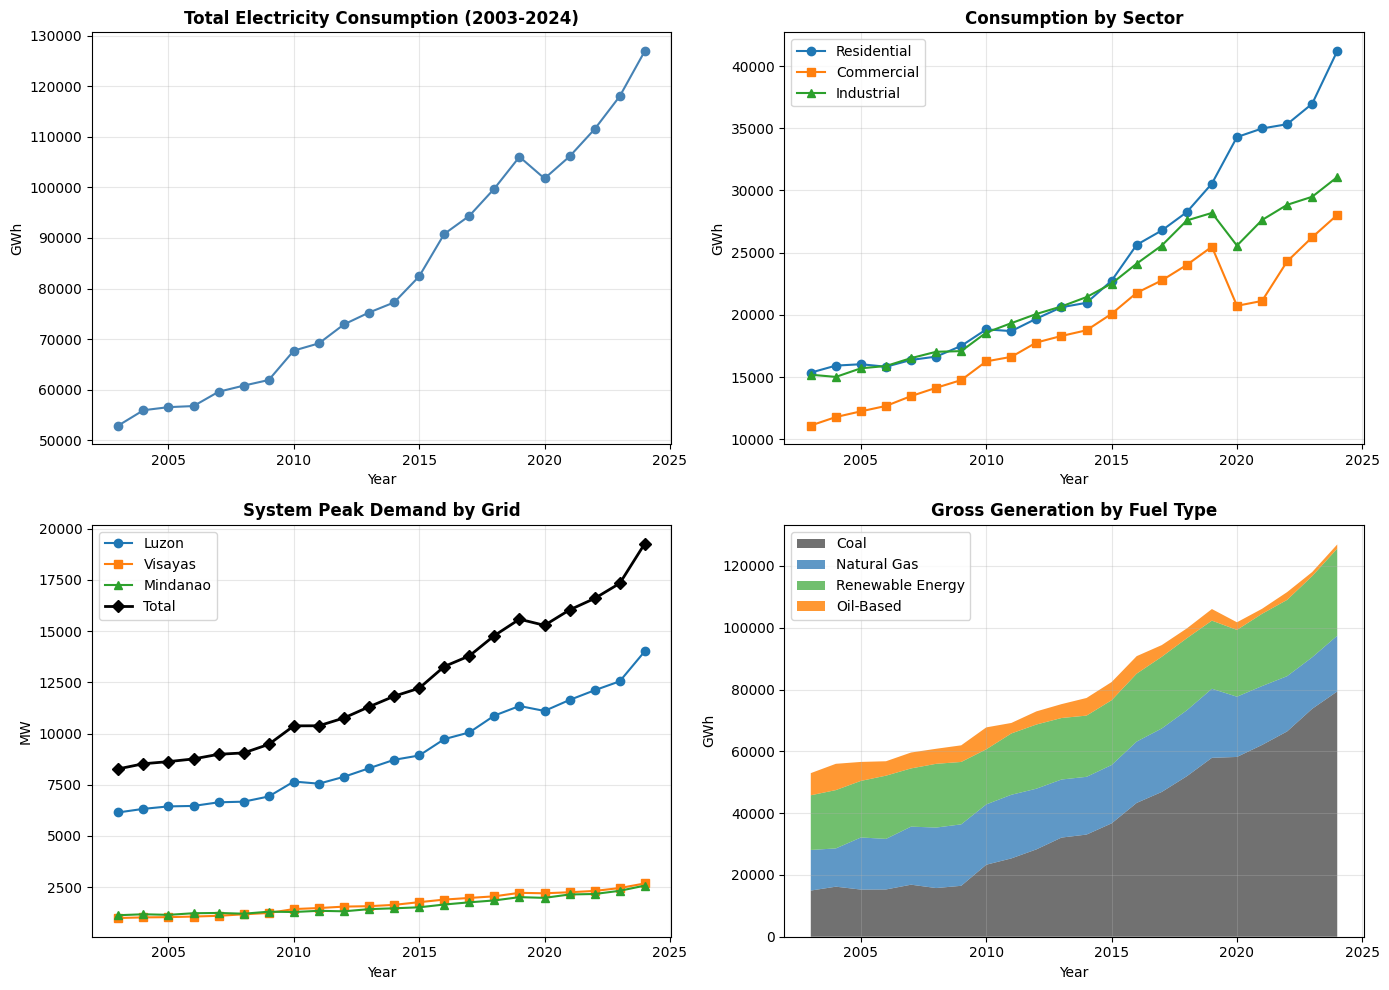


Key observations:
1. Clear upward trend in total consumption (~139% growth from 2003 to 2024).
2. 2020 shows a visible dip due to COVID-19 economic slowdown.
3. Coal dominates generation, but renewables are growing rapidly (especially solar after 2015).
4. Peak demand growth roughly tracks consumption growth.


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Total Consumption Trend
axes[0,0].plot(master.index, master['total_consumption_gwh'], marker='o', color='steelblue')
axes[0,0].set_title('Total Electricity Consumption (2003-2024)', fontsize=12, weight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('GWh')
axes[0,0].grid(True, alpha=0.3)

# 2. Sector Breakdown
axes[0,1].plot(master.index, master['residential_consumption_gwh'], label='Residential', marker='o')
axes[0,1].plot(master.index, master['commercial_consumption_gwh'], label='Commercial', marker='s')
axes[0,1].plot(master.index, master['industrial_consumption_gwh'], label='Industrial', marker='^')
axes[0,1].set_title('Consumption by Sector', fontsize=12, weight='bold')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('GWh')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Peak Demand
axes[1,0].plot(master.index, master['luzon_peak_demand_mw'], label='Luzon', marker='o')
axes[1,0].plot(master.index, master['visayas_peak_demand_mw'], label='Visayas', marker='s')
axes[1,0].plot(master.index, master['mindanao_peak_demand_mw'], label='Mindanao', marker='^')
axes[1,0].plot(master.index, master['total_peak_demand_mw'], label='Total', marker='D', color='black', linewidth=2)
axes[1,0].set_title('System Peak Demand by Grid', fontsize=12, weight='bold')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('MW')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Generation Mix (Stacked Area)
axes[1,1].stackplot(
    master.index,
    master['coal_generation_gwh'],
    master['natural_gas_generation_gwh'],
    master['renewable_generation_gwh'],
    master['oil_based_generation_gwh'],
    labels=['Coal', 'Natural Gas', 'Renewable Energy', 'Oil-Based'],
    colors=['#4d4d4d', '#377eb8', '#4daf4a', '#ff7f00'],
    alpha=0.8
)
axes[1,1].set_title('Gross Generation by Fuel Type', fontsize=12, weight='bold')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('GWh')
axes[1,1].legend(loc='upper left')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey observations:')
print('1. Clear upward trend in total consumption (~139% growth from 2003 to 2024).')
print('2. 2020 shows a visible dip due to COVID-19 economic slowdown.')
print('3. Coal dominates generation, but renewables are growing rapidly (especially solar after 2015).')
print('4. Peak demand growth roughly tracks consumption growth.')


## Step 6: Time-Series Preprocessing for ARIMA

ARIMA requires the series to be **stationary** — meaning its statistical properties (mean, variance) do not change over time.

We test stationarity using the **Augmented Dickey-Fuller (ADF) test**:
- **Null hypothesis (H0):** The series has a unit root (non-stationary).
- **Alternative hypothesis (H1):** The series is stationary.
- If p-value < 0.05, we reject H0 and conclude the series is stationary.

If non-stationary, we apply **differencing** (`d` parameter in ARIMA) until stationarity is achieved.


In [16]:
def adf_test(series, name='Series'):
    '''
    Perform Augmented Dickey-Fuller test and print results.
    '''
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\n=== ADF Test: {name} ===')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    if result[1] < 0.05:
        print('=> STATIONARY (Reject H0)')
    else:
        print('=> NON-STATIONARY (Fail to reject H0)')
    return result

# Test our primary target: Total Consumption
adf_consumption = adf_test(master['total_consumption_gwh'], 'Total Electricity Consumption')

# Also test peak demand
adf_peak = adf_test(master['total_peak_demand_mw'], 'Total Peak Demand')

# Test renewable generation (often more volatile)
adf_renewable = adf_test(master['renewable_generation_gwh'], 'Renewable Generation')



=== ADF Test: Total Electricity Consumption ===
ADF Statistic: -1.4375
p-value: 0.5642
Critical Values:
   1%: -4.1378
   5%: -3.1550
   10%: -2.7145
=> NON-STATIONARY (Fail to reject H0)

=== ADF Test: Total Peak Demand ===
ADF Statistic: 0.0931
p-value: 0.9656
Critical Values:
   1%: -4.1378
   5%: -3.1550
   10%: -2.7145
=> NON-STATIONARY (Fail to reject H0)

=== ADF Test: Renewable Generation ===
ADF Statistic: 49.6838
p-value: 1.0000
Critical Values:
   1%: -4.1378
   5%: -3.1550
   10%: -2.7145
=> NON-STATIONARY (Fail to reject H0)


### 6.1 Differencing to Achieve Stationarity

If the ADF test shows non-stationarity, we apply **first-order differencing**:

Delta y_t = y_t - y_{t-1}

This removes linear trend. We then re-test.

**Important:** With only 22 observations, each difference costs us 1 row. We cannot afford more than 1 or 2 differencing steps.


After 1st-order differencing:

=== ADF Test: Total Consumption (1st Diff) ===
ADF Statistic: -1.1180
p-value: 0.7078
Critical Values:
   1%: -4.0120
   5%: -3.1042
   10%: -2.6910
=> NON-STATIONARY (Fail to reject H0)

=== ADF Test: Peak Demand (1st Diff) ===
ADF Statistic: -1.6077
p-value: 0.4797
Critical Values:
   1%: -4.1378
   5%: -3.1550
   10%: -2.7145
=> NON-STATIONARY (Fail to reject H0)


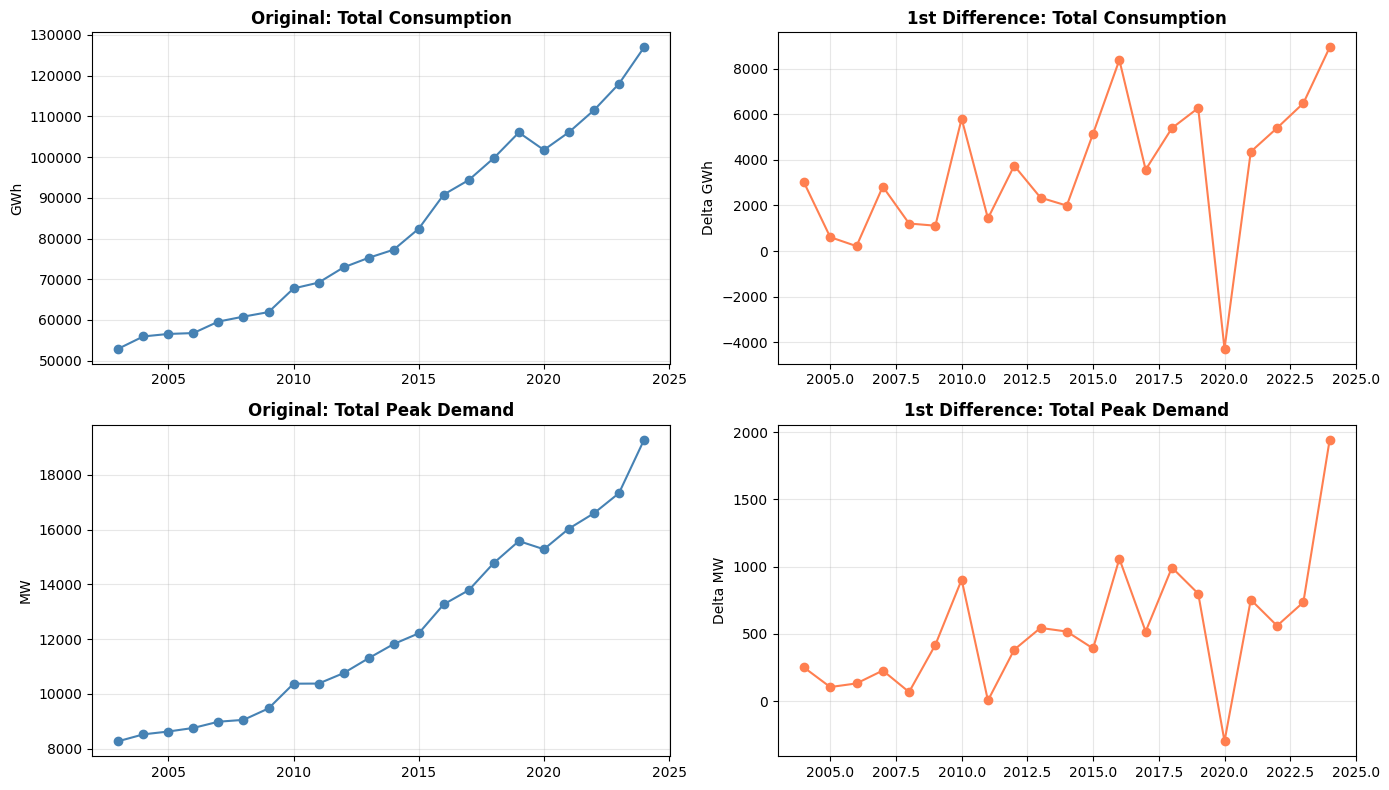

In [17]:
# First-order difference for consumption
master['total_consumption_diff1'] = master['total_consumption_gwh'].diff()
master['total_peak_demand_diff1'] = master['total_peak_demand_mw'].diff()
master['renewable_generation_diff1'] = master['renewable_generation_gwh'].diff()

# Re-run ADF on differenced series
print('After 1st-order differencing:')
adf_consumption_diff = adf_test(master['total_consumption_diff1'].dropna(), 'Total Consumption (1st Diff)')
adf_peak_diff = adf_test(master['total_peak_demand_diff1'].dropna(), 'Peak Demand (1st Diff)')

# Plot original vs differenced
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(master.index, master['total_consumption_gwh'], marker='o', color='steelblue')
axes[0,0].set_title('Original: Total Consumption', weight='bold')
axes[0,0].set_ylabel('GWh')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(master.index, master['total_consumption_diff1'], marker='o', color='coral')
axes[0,1].set_title('1st Difference: Total Consumption', weight='bold')
axes[0,1].set_ylabel('Delta GWh')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(master.index, master['total_peak_demand_mw'], marker='o', color='steelblue')
axes[1,0].set_title('Original: Total Peak Demand', weight='bold')
axes[1,0].set_ylabel('MW')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(master.index, master['total_peak_demand_diff1'], marker='o', color='coral')
axes[1,1].set_title('1st Difference: Total Peak Demand', weight='bold')
axes[1,1].set_ylabel('Delta MW')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stationarity_check.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 ACF and PACF Plots for ARIMA Parameter Selection

To select `p` (AR order) and `q` (MA order), we examine:
- **ACF (Autocorrelation Function):** Correlation between y_t and y_{t-k}. The lag where ACF cuts off suggests `q`.
- **PACF (Partial Autocorrelation Function):** Correlation between y_t and y_{t-k} controlling for intermediate lags. The lag where PACF cuts off suggests `p`.

**Rule of thumb:**
- If PACF drops off after lag `p` -> AR(p) model.
- If ACF drops off after lag `q` -> MA(q) model.

With only 22 observations, we expect small `p` and `q` (likely 0, 1, or 2).


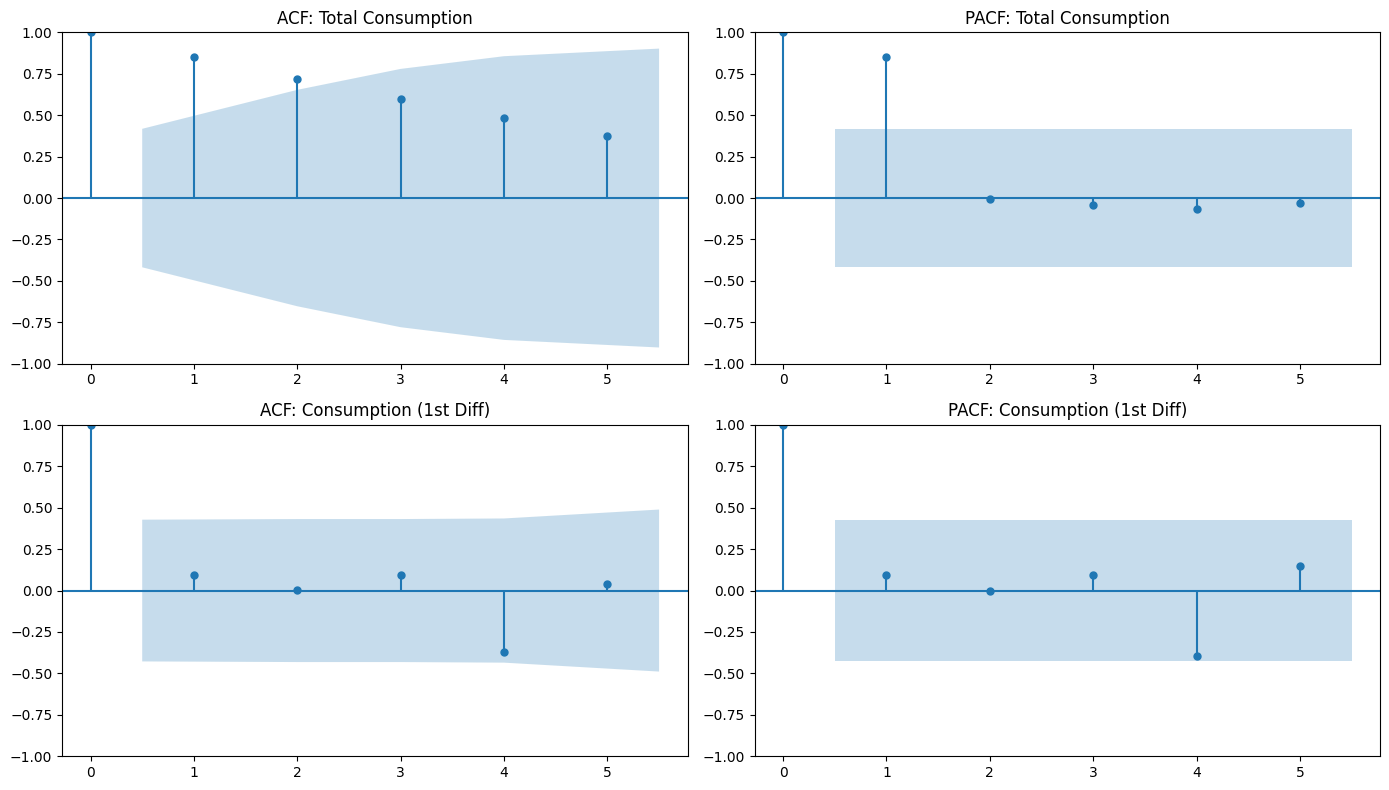


Interpretation guide:
- If PACF has a significant spike at lag 1 and cuts off => p=1
- If ACF has a significant spike at lag 1 and cuts off => q=1
- Significant spikes beyond lag 2 are unreliable with n=22 (high variance).


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF / PACF for original consumption
plot_acf(master['total_consumption_gwh'].dropna(), lags=5, ax=axes[0,0], title='ACF: Total Consumption')
plot_pacf(master['total_consumption_gwh'].dropna(), lags=5, ax=axes[0,1], title='PACF: Total Consumption')

# ACF / PACF for differenced consumption
plot_acf(master['total_consumption_diff1'].dropna(), lags=5, ax=axes[1,0], title='ACF: Consumption (1st Diff)')
plot_pacf(master['total_consumption_diff1'].dropna(), lags=5, ax=axes[1,1], title='PACF: Consumption (1st Diff)')

plt.tight_layout()
plt.savefig('acf_pacf_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretation guide:')
print('- If PACF has a significant spike at lag 1 and cuts off => p=1')
print('- If ACF has a significant spike at lag 1 and cuts off => q=1')
print('- Significant spikes beyond lag 2 are unreliable with n=22 (high variance).')


## Step 7: Feature Engineering for ARIMA

Even though ARIMA itself is univariate, we can create **exogenous features** to enrich a SARIMAX model. We also engineer features for potential hybrid models or for post-hoc analysis.

### 7.1 Temporal / Calendar Features


In [19]:
# Since we only have annual data, seasonality is yearly (period=1).
# We still create useful trend features.
master['year'] = master.index.astype(int)
master['years_since_2003'] = master['year'] - 2003

# Growth rates (year-over-year)
master['consumption_yoy_growth'] = master['total_consumption_gwh'].pct_change() * 100
master['peak_yoy_growth'] = master['total_peak_demand_mw'].pct_change() * 100
master['renewable_share_pct'] = (master['renewable_generation_gwh'] / master['total_consumption_gwh']) * 100

# Lag features (for potential supervised learning baseline)
master['consumption_lag1'] = master['total_consumption_gwh'].shift(1)
master['consumption_lag2'] = master['total_consumption_gwh'].shift(2)
master['peak_lag1'] = master['total_peak_demand_mw'].shift(1)

# Rolling averages
master['consumption_roll3'] = master['total_consumption_gwh'].rolling(window=3, min_periods=1).mean()
master['consumption_roll5'] = master['total_consumption_gwh'].rolling(window=5, min_periods=1).mean()

# Capacity margin (supply buffer)
master['capacity_margin_mw'] = master['total_dependable_capacity_mw'] - master['total_peak_demand_mw']
master['capacity_margin_pct'] = (master['capacity_margin_mw'] / master['total_peak_demand_mw']) * 100

print('Feature engineering complete.')
print('New columns added:')
new_cols = [c for c in master.columns if c not in [
    'total_consumption_gwh','residential_consumption_gwh','commercial_consumption_gwh',
    'industrial_consumption_gwh','others_consumption_gwh','electricity_sales_gwh',
    'utilities_own_use_gwh','system_losses_gwh','luzon_peak_demand_mw',
    'visayas_peak_demand_mw','mindanao_peak_demand_mw','total_peak_demand_mw',
    'luzon_generation_gwh','visayas_generation_gwh','mindanao_generation_gwh',
    'coal_generation_gwh','oil_based_generation_gwh','natural_gas_generation_gwh',
    'renewable_generation_gwh','geothermal_generation_gwh','hydro_generation_gwh',
    'biomass_generation_gwh','solar_generation_gwh','wind_generation_gwh',
    'combined_cycle_generation_gwh','diesel_generation_gwh','gas_turbine_generation_gwh',
    'oil_thermal_generation_gwh','total_installed_capacity_mw','total_dependable_capacity_mw'
]]
for c in new_cols:
    print(f'  - {c}')

print('\nPreview of engineered features:')
print(master[['year', 'total_consumption_gwh', 'consumption_yoy_growth', 
              'renewable_share_pct', 'capacity_margin_pct']].head())


Feature engineering complete.
New columns added:
  - total_consumption_diff1
  - total_peak_demand_diff1
  - renewable_generation_diff1
  - year
  - years_since_2003
  - consumption_yoy_growth
  - peak_yoy_growth
  - renewable_share_pct
  - consumption_lag1
  - consumption_lag2
  - peak_lag1
  - consumption_roll3
  - consumption_roll5
  - capacity_margin_mw
  - capacity_margin_pct

Preview of engineered features:
      year  total_consumption_gwh  consumption_yoy_growth  \
year                                                        
2003  2003                  52941                     NaN   
2004  2004                  55957                5.696908   
2005  2005                  56568                1.091910   
2006  2006                  56784                0.381841   
2007  2007                  59612                4.980276   

      renewable_share_pct  capacity_margin_pct  
year                                            
2003            33.418334            61.981873  
2004    

## Step 8: Train / Test Split

For time series, we **never** use random splitting — that would leak future information into training.

**Strategy:**
- **Train:** 2003-2020 (18 years)
- **Test:** 2021-2024 (4 years)

This preserves temporal causality. We train on the past and evaluate on the most recent years, simulating real-world deployment.


Train set: 2003-2020 (18 observations)
Test set:  2021-2024 (4 observations)


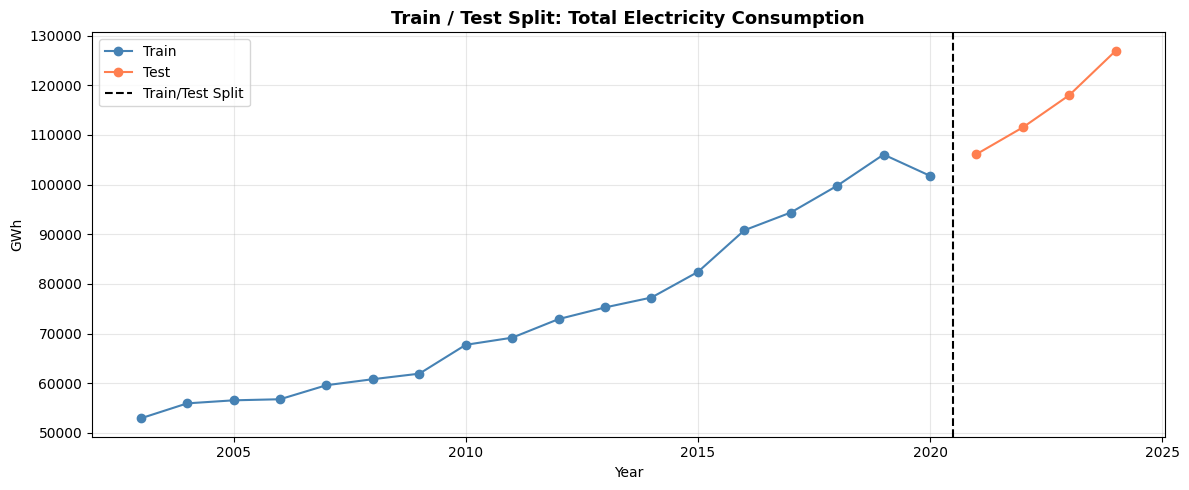

In [20]:
# Time-based split
train = master.loc[master.index <= 2020].copy()
test = master.loc[master.index >= 2021].copy()

print(f'Train set: {train.index.min()}-{train.index.max()} ({len(train)} observations)')
print(f'Test set:  {test.index.min()}-{test.index.max()} ({len(test)} observations)')

# Visualize the split
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index, train['total_consumption_gwh'], label='Train', color='steelblue', marker='o')
ax.plot(test.index, test['total_consumption_gwh'], label='Test', color='coral', marker='o')
ax.axvline(x=2020.5, color='black', linestyle='--', label='Train/Test Split')
ax.set_title('Train / Test Split: Total Electricity Consumption', fontsize=13, weight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('GWh')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 9: Save ML-Ready Outputs

We save three files:
1. `master_preprocessed.csv` — the full engineered dataset (train + test)
2. `train_arima.csv` — training set for model fitting
3. `test_arima.csv` — test set for evaluation
4. `arima_ready_consumption.csv` — univariate series with year index, ready for `statsmodels.tsa.arima.ARIMA`


In [21]:
# Save master dataset
master.to_csv('master_preprocessed.csv')
print('Saved: master_preprocessed.csv')

# Save train/test splits
train.to_csv('train_arima.csv')
test.to_csv('test_arima.csv')
print('Saved: train_arima.csv, test_arima.csv')

# Save ARIMA-ready univariate series
arima_ready = master[['year', 'total_consumption_gwh', 'total_consumption_diff1']].copy()
arima_ready.to_csv('arima_ready_consumption.csv', index=True)
print('Saved: arima_ready_consumption.csv')

print('\nAll preprocessing complete!')
print('\nNext steps for ARIMA modeling:')
print('1. Load train_arima.csv')
print('2. Fit ARIMA(p,d,q) on train[total_consumption_gwh] or the differenced series')
print('3. Forecast 2021-2024 and compare against test[total_consumption_gwh]')
print('4. Evaluate with MAE, RMSE, MAPE')


Saved: master_preprocessed.csv
Saved: train_arima.csv, test_arima.csv
Saved: arima_ready_consumption.csv

All preprocessing complete!

Next steps for ARIMA modeling:
1. Load train_arima.csv
2. Fit ARIMA(p,d,q) on train[total_consumption_gwh] or the differenced series
3. Forecast 2021-2024 and compare against test[total_consumption_gwh]
4. Evaluate with MAE, RMSE, MAPE


## Appendix: Data Dictionary

| Column | Description | Unit |
|---|---|---|
| `year` | Calendar year | integer |
| `total_consumption_gwh` | Total national electricity consumption | GWh |
| `residential_consumption_gwh` | Residential sector consumption | GWh |
| `commercial_consumption_gwh` | Commercial sector consumption | GWh |
| `industrial_consumption_gwh` | Industrial sector consumption | GWh |
| `system_losses_gwh` | Transmission and distribution losses | GWh |
| `total_peak_demand_mw` | National non-coincident peak demand | MW |
| `luzon_peak_demand_mw` | Luzon grid peak demand | MW |
| `renewable_generation_gwh` | Total renewable energy generation | GWh |
| `renewable_share_pct` | Renewables as % of total consumption | % |
| `consumption_yoy_growth` | Year-over-year consumption growth | % |
| `capacity_margin_pct` | Buffer between dependable capacity and peak demand | % |
| `total_consumption_diff1` | First-order difference of consumption | GWh |

